In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('evaluation_details/evaluation_pdfs/average_metrics.csv')
df['model_short'] = df['model_name'].apply(lambda x: x.split('/')[-1][:28])

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
def plot_quality_radar():
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    quality_metrics = ['context_recall', 'faithfulness', 'factual_correctness(mode=f1)']
    angles = np.linspace(0, 2 * np.pi, len(quality_metrics), endpoint=False).tolist()
    angles += angles[:1]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(df)))
    
    for idx, row in df.iterrows():
        values = [row[col] for col in quality_metrics]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row['model_short'], color=colors[idx])
        ax.fill(angles, values, alpha=0.15, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Context Recall', 'Faithfulness', 'Factual Correctness'], fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_title('RAGAS Metrics Profile', fontsize=15, fontweight='bold', pad=20)
    ax.grid(True)

    ncol = min(3, max(1, len(df) // 8 + 1))
    legend = ax.legend(
        loc='upper right',
        bbox_to_anchor=(1.35, 1.05),
        title='Models',
        title_fontsize=12,
        fontsize=11,
        ncol=ncol,
        frameon=True,
        framealpha=0.95,
        markerscale=1.6,
        labelspacing=0.6,
        handletextpad=0.5
    )

    plt.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()

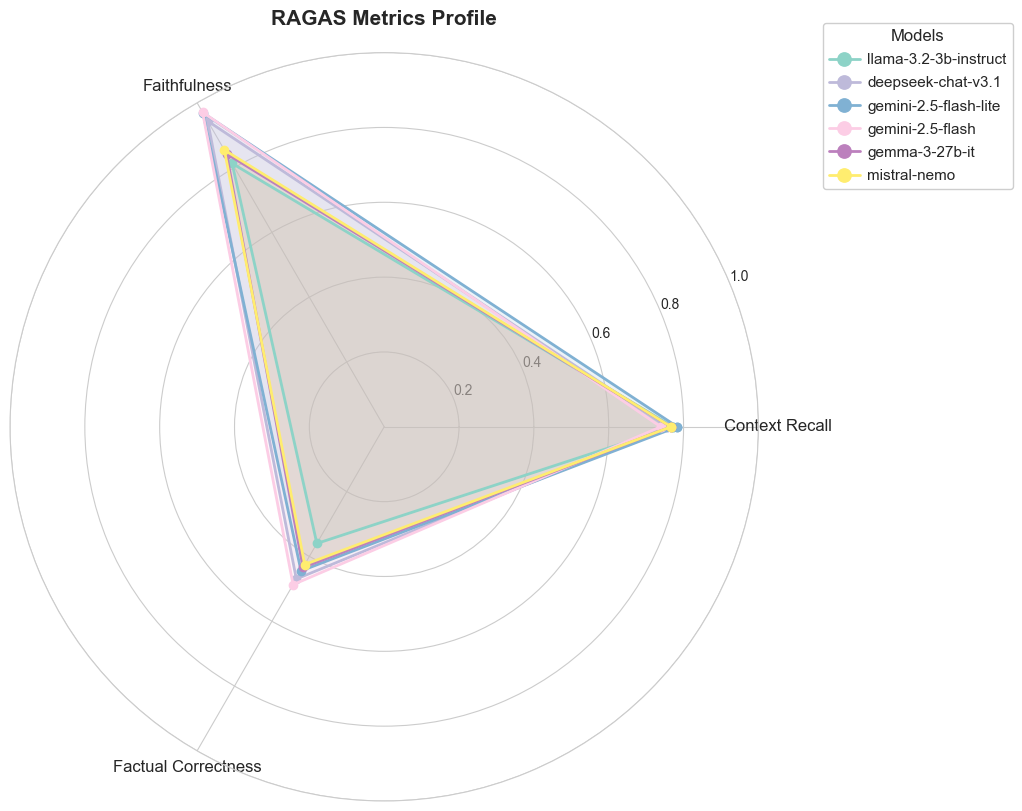

In [117]:
plot_quality_radar()

In [ ]:
def plot_sentence_structure():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    colors = plt.cm.Pastel1(np.linspace(0, 1, len(df)))
    x = np.arange(len(df))
    bar_width = 0.88

    bars1 = ax1.bar(x, df['avg_word_length'], width=bar_width, color=colors, edgecolor='black')
    ax1.set_xlabel('Models', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Average Word Length', fontsize=14, fontweight='bold')
    ax1.set_title('Average Word Length by Model', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['model_short'], rotation=45, ha='right', fontsize=16)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_xlim(-0.5, len(df) - 0.5)
    ax1.set_ylim(0, 8)

    max_w = max(df['avg_word_length'].max(), 1)
    for bar in bars1:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2.,
            h + 0.02 * max_w,
            f'{h:.2f}',
            ha='center', va='bottom',
            fontsize=14
        )

    bars2 = ax2.bar(x, df['avg_sentence_length'], width=bar_width, color=colors, edgecolor='black')
    ax2.set_xlabel('Models', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Average Sentence Length', fontsize=14, fontweight='bold')
    ax2.set_title('Average Sentence Length by Model', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(df['model_short'], rotation=45, ha='right', fontsize=16)
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_xlim(-0.5, len(df) - 0.5)
    ax2.set_ylim(0, 40)

    max_s = max(df['avg_sentence_length'].max(), 1)
    for bar in bars2:
        h = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width() / 2.,
            h + 0.02 * max_s,
            f'{h:.2f}',
            ha='center', va='bottom',
            fontsize=14
        )

    plt.suptitle('Sentence Structure Comparison', fontsize=16, fontweight='bold', y=0.98)
    plt.subplots_adjust(wspace=0.32, top=0.86, bottom=0.15)
    plt.show()

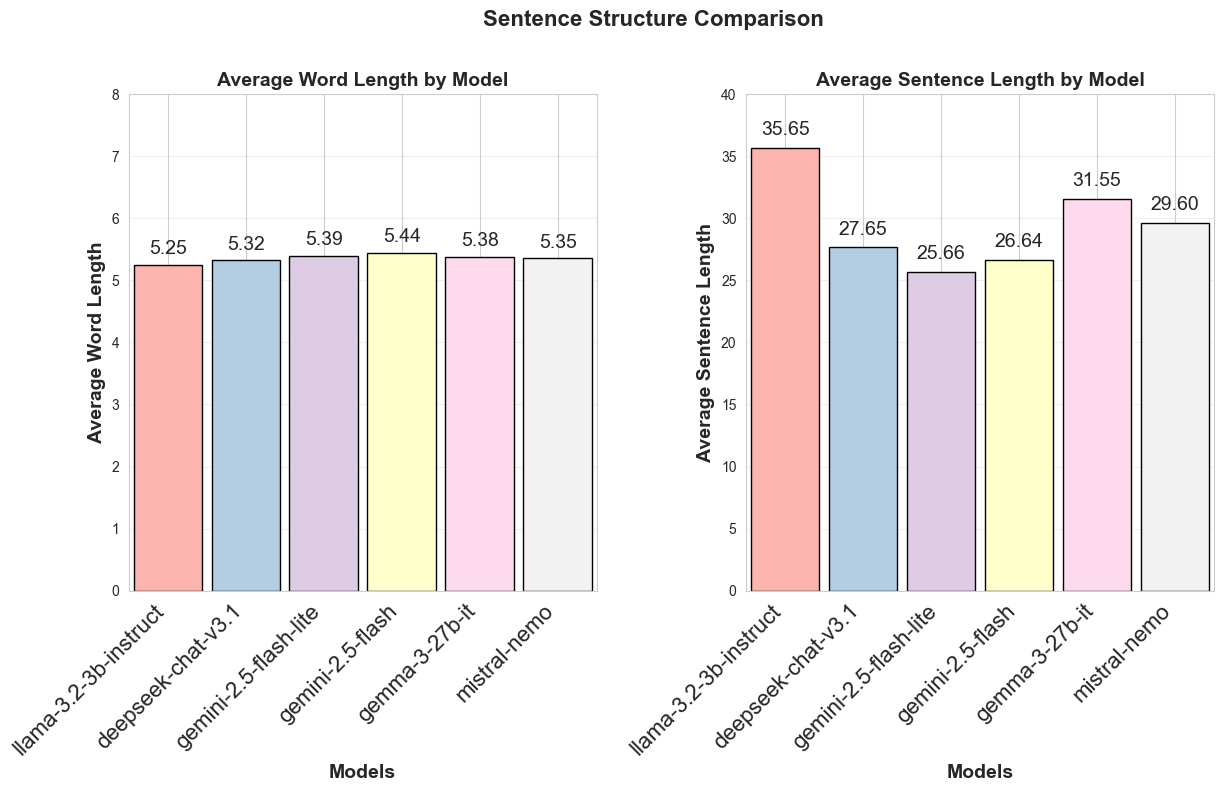

In [118]:
plot_sentence_structure()

In [ ]:
def plot_faithfulness_vs_factuality():
    fig, ax = plt.subplots(figsize=(14, 10))
    
    x_col = 'faithfulness'
    y_col = 'factual_correctness(mode=f1)'
    
    bubble_size = 300
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue='model_short',
        s=bubble_size,
        palette='tab10',
        edgecolor='black',
        linewidth=1.0,
        alpha=0.85,
        ax=ax
    )
    
    label_dx = 16
    label_dy = 6
    for i, row in df.iterrows():
        ax.annotate(
            row['model_short'],
            (row[x_col], row[y_col]),
            xytext=(label_dx, label_dy),
            textcoords='offset points',
            fontsize=14,
            weight='normal',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.75),
            ha='left',
            va='center'
        )
    
    ax.set_xlabel('Faithfulness', fontsize=15, fontweight='bold')
    ax.set_ylabel('Factual Correctness (F1)', fontsize=15, fontweight='bold')
    ax.set_title('Hallucination Risk Analysis', fontsize=18, fontweight='bold', pad=20)
    
    ncol = min(3, max(1, len(df) // 8 + 1))
    legend = ax.legend(
        bbox_to_anchor=(1.20, 1),
        loc='upper left',
        title='Models',
        title_fontsize=14,
        fontsize=14,
        ncol=ncol,
        frameon=True,
        markerscale=1.0,
        borderpad=0.6
    )
    if legend:
        for text in legend.get_texts():
            text.set_weight('normal')
    
    ax.axvline(x=df[x_col].mean(), color='gray', linestyle='--', alpha=0.6)
    ax.axhline(y=df[y_col].mean(), color='gray', linestyle='--', alpha=0.6)
    
    plt.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()

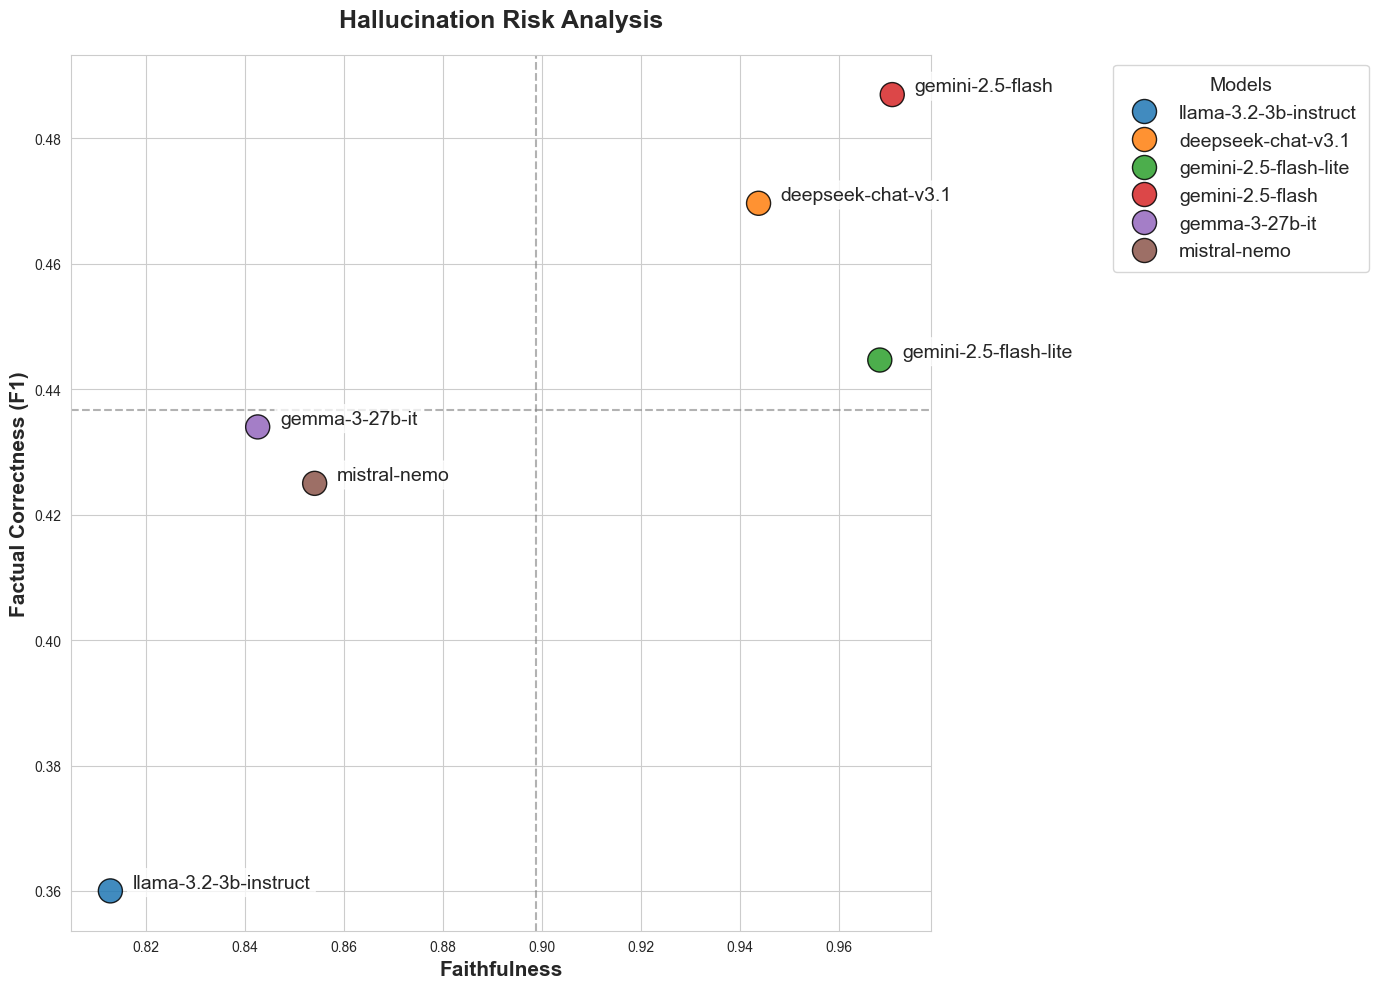

In [120]:
plot_faithfulness_vs_factuality()

In [ ]:
def plot_efficiency_scatter():
    fig, ax = plt.subplots(figsize=(12, 8))
    
    x = df['average_reasoning_steps']
    y = df['factual_correctness(mode=f1)']
    
    bubble_size = 400
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue='model_short',
        s=bubble_size,
        palette='viridis',
        edgecolor='black',
        linewidth=1.0,
        alpha=0.85,
        ax=ax
    )
    
    label_dx = 17
    label_dy = 6
    for i, row in df.iterrows():
        ax.annotate(
            row['model_short'],
            (row['average_reasoning_steps'], row['factual_correctness(mode=f1)']),
            xytext=(label_dx, label_dy),
            textcoords='offset points',
            fontsize=14,
            weight='normal',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.75),
            ha='left',
            va='center'
        )

    ax.set_title('Reasoning Efficiency', fontsize=16, fontweight='bold')
    ax.set_xlabel('Average Reasoning Steps (Effort)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Factual Correctness (Result)', fontsize=14, fontweight='bold')
    

    ncol = min(3, max(1, len(df) // 8 + 1))
    legend = ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        title='Models',
        title_fontsize=13,
        fontsize=13,
        ncol=ncol,
        frameon=True,
        markerscale=0.8,
        borderpad=0.6
    )
    if legend:
        for text in legend.get_texts():
            text.set_weight('normal')

    plt.subplots_adjust(right=0.80)
    plt.tight_layout()
    plt.show()

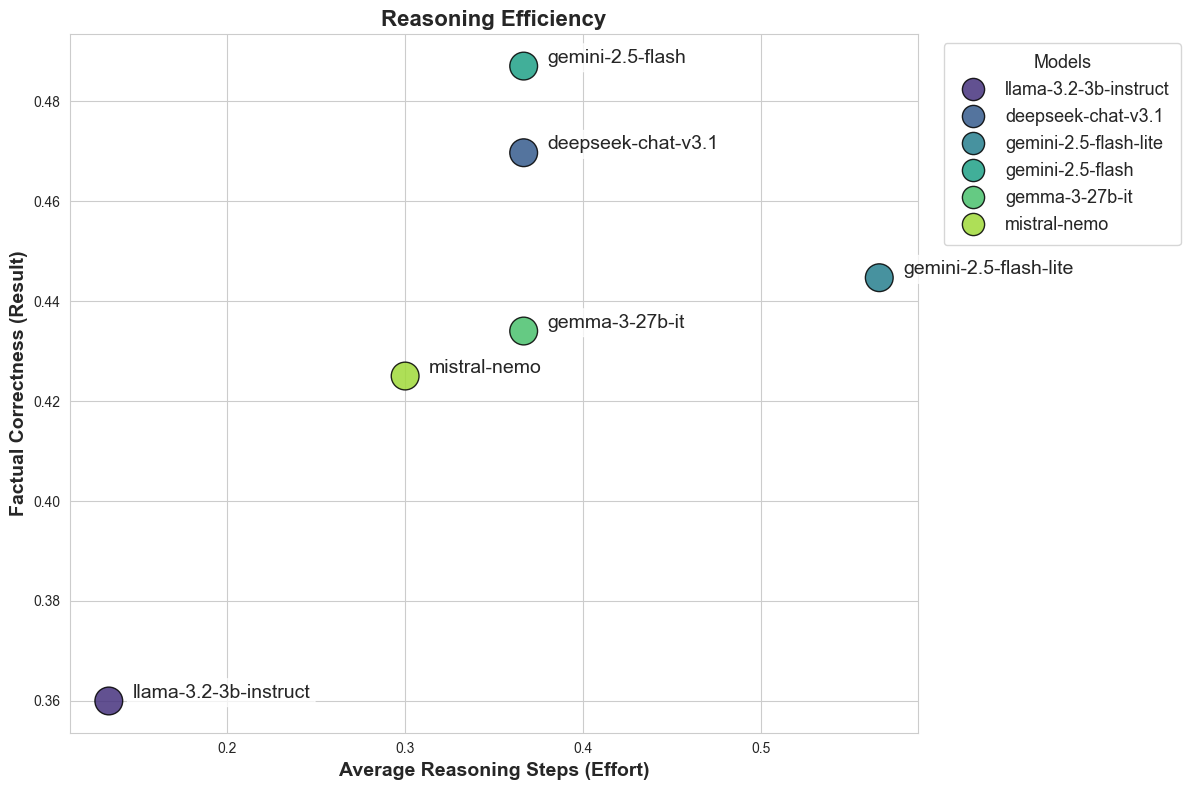

In [122]:
plot_efficiency_scatter()

In [ ]:
def plot_complexity_profile():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    metrics_cols = [
        'flesch_reading_ease',
        'gunning_fog',
        'type_token_ratio',
        'embedding_diversity'
    ]
    metric_labels = [
        'Flesch Reading Ease',
        'Gunning Fog Index',
        'Type-Token Ratio',
        'Embedding Diversity'
    ]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(df)))
    
    for idx, (col, label) in enumerate(zip(metrics_cols, metric_labels)):
        ax = axes[idx]
        
        x_pos = np.arange(len(df))
        bars = ax.bar(
            x_pos,
            df[col],
            color=colors,
            edgecolor='black',
            linewidth=1.5,
            alpha=0.8
        )
        
        for bar, value in zip(bars, df[col]):
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2.,
                height,
                f'{value:.2f}',
                ha='center',
                va='bottom',
                fontsize=12,
                fontweight='bold'
            )
        
        ax.set_xlabel('Models', fontsize=11, fontweight='bold', labelpad=8)
        ax.set_ylabel(label, fontsize=11, fontweight='bold')
        
        ax.set_title(label, fontsize=12, fontweight='bold', pad=12)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(
            df['model_short'],
            rotation=45,
            ha='right',
            fontsize=12
        )
        
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=11)
        
        for spine in ax.spines.values():
            spine.set_linewidth(1.6)
    
    plt.suptitle(
        'Language Quality Metrics Across Models',
        fontsize=16,
        fontweight='bold',
        y=0.98
    )
    
    plt.subplots_adjust(
        hspace=0.75,
        top=0.90,
        bottom=0.12
    )
    
    plt.show()

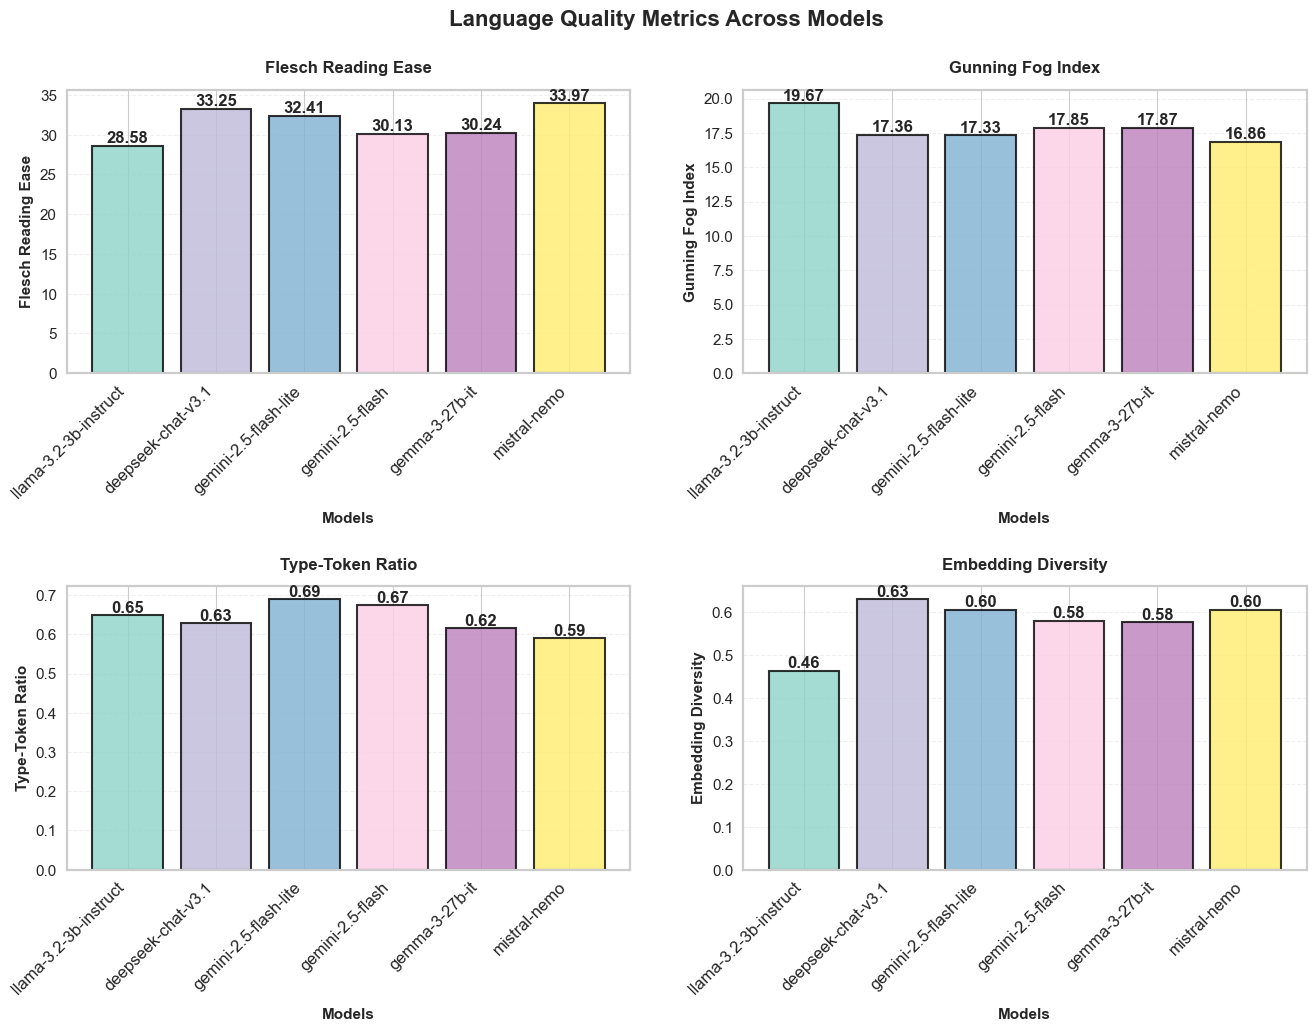

In [125]:
plot_complexity_profile()